# Самостоятельная работа. Анализ и обработка больших данных с Dask


**Цель работы:** закрепить навыки построения базовых ETL-конвейеров (Extract, Transform, Load) для обработки больших массивов данных средствами библиотеки Dask, освоить принципы ленивых (lazy) вычислений, управление памятью и визуализацию графов задач (DAG).

---
### Исходные данные
Каталог датасетов расположен по ссылке: [Yandex Disk](https://disk.yandex.ru/d/fbPE3VNKYocd7g)

### Описание задания
Вам необходимо построить Dask-пайплайн, строго следуя концепции ETL, избегая переполнения оперативной памяти:

1. **Extract (Извлечение данных)**
    * Настройте локальный кластер `Dask Client` с оптимальными параметрами для вашей среды (без жестких ограничений памяти, чтобы избежать ошибки `KilledWorker`).
    * Подключите директорию с данными и считайте ваш вариант датасета (см. таблицу ниже), используя `dask.dataframe.read_csv` (при необходимости распакуйте архив).

2. **Transform (Трансформация и очистка)**
    * Проведите профилирование качества данных: вычислите процент пропущенных значений для каждого столбца. Метод `.compute()` используйте *только* для получения финального небольшого результата (списка процентов).
    * На основе полученной статистики сформируйте список столбцов, в которых более 60% пропусков.
    * «Лениво» (без вызова `compute()`) удалите эти столбцы из основного Dask DataFrame.

3. **Load (Загрузка результатов)**
    * Чтобы завершить ETL-цикл, сохраните очищенный Dask DataFrame обратно на диск в виде набора файлов.
    * Используйте функцию `.to_parquet('cleaned_data.parquet')` или `.to_csv('cleaned_data-*.csv')`. Это позволит Dask обработать и сохранить огромный массив данных по частям, не загружая его целиком в RAM.

4. **Визуализация графов вычислений (DAG)**
    * Используя декоратор или функцию `dask.delayed`, создайте логику из нескольких простых python-функций (например, фильтрация, агрегация, математические вычисления).
    * Постройте простой ориентированный ациклический граф (DAG) с одним узлом и его зависимостями. Визуализируйте его методом `.visualize()`.
    * Постройте сложный двухуровневый DAG (используя списковые включения или циклы для имитации map-reduce операций). Визуализируйте результат.

Каталог датасетов [тут](https://disk.yandex.ru/d/fbPE3VNKYocd7g). Прямая ссылка https://disk.yandex.ru/d/fbPE3VNKYocd7g.




### Таблица вариантов

Выберите ваш набор данных в зависимости от номера варианта:

| Вариант | Имя файла (Датасет для ETL) |
| :---: | :--- |
| **1, 7, 13, 19, 25** | `Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv` |
| **2, 8, 14, 20** | `Parking_Violations_Issued_-_Fiscal_Year_2015.csv` |
| **3, 9, 15, 21** | `Parking_Violations_Issued_-_Fiscal_Year_2016.csv` |
| **4, 10, 16, 22** | `Parking_Violations_Issued_-_Fiscal_Year_2017.csv` |
| **5, 11, 17, 23** | `UK Property Price official data 1995-202304.zip` |
| **6, 12, 18, 24** | `Austin, TX House Listings.zip` |

In [1]:
# Подготовка окружения
!pip install "dask[complete]" graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00


In [2]:
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# Инициализация клиента Dask (Оптимизированные настройки без жесткого лимита памяти)
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36525
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43801'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34167'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38469 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38469
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:51654
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:34345 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34345
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36525,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34345,Total threads: 2
Dashboard: http://127.0.0.1:35785/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:43801,


#### Шаг 1. Extract (Извлечение данных)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
ls

In [7]:
# import libraries
import sys
import os

## import dask libraries
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

# import libraries
import pandas as pd

In [8]:
cwd = os.getcwd()

# print
print('', sys.executable)
print('', cwd)

 /usr/bin/python3
 /content/drive/MyDrive


In [9]:
## read data using DataFrame API
dtypes = {
    'Issuer Command': 'object',
    'Issuer Squad': 'object',
    'House Number': 'object',
    'Time First Observed': 'object',
    'Violation Description': 'object',
    'Violation Legal Code': 'object',
    'Violation Post Code': 'object',
    'Unregistered Vehicle?': 'float64',
    'Violation Location': 'float64',

    'Date First Observed': 'float64',
    'Feet From Curb': 'float64',
    'Law Section': 'float64',
    'Vehicle Year': 'float64'
}

df = dd.read_csv('Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv',  dtype=dtypes)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
npartitions=29,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,string,int64,string,string,string,int64,int64,int64,int64,float64,int64,int64,int64,string,string,string,string,string,string,string,string,string,float64,float64,string,string,string,string,string,string,float64,float64,string,float64,string,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


#### Шаг 2. Transform (Трансформация и очистка данных)

In [10]:
df['Issue Date'] = dd.to_datetime(df['Issue Date'], format='%m/%d/%Y')


In [11]:
# count missing values
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
BBL               int64
Violation Time      ...
Dask Name: sum, 8 expressions
Expr=(~ NotNull(frame=Assign(frame=ArrowStringConversion(frame=FromMapProjectable(e513144))))).sum()

In [12]:
# calculate percent missing values
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)
missing_count

Dask Series Structure:
npartitions=1
BBL               float64
Violation Time        ...
Dask Name: mul, 12 expressions
Expr=(~ NotNull(frame=Assign(frame=ArrowStringConversion(frame=FromMapProjectable(e513144))))).sum() / Index(frame=Assign(frame=ArrowStringConversion(frame=FromMapProjectable(e513144)))).size() * 100

In [13]:
# запуск вычисления, используя метод подсчета
with ProgressBar():
  missing_count_percent = missing_count.compute()
missing_count_percent

,0
Summons Number,0.000000
Plate ID,0.039691
Registration State,0.000000
Plate Type,0.000000
Issue Date,0.000000
Violation Code,0.000000
Vehicle Body Type,1.223886
Vehicle Make,0.695286
Issuing Agency,0.000000
Street Code1,0.000000


In [15]:
# 1. Получаем список столбцов для удаления
columns_to_drop = list(missing_count_percent[missing_count_percent > 55].index)
print("Столбцы на удаление:", columns_to_drop)

# 2. Оптимизация
df_dropped = df.drop(columns=columns_to_drop)

# 3. Проверка результата
df_dropped.head()


Столбцы на удаление: ['Time First Observed', 'Intersecting Street', 'Violation Legal Code', 'Unregistered Vehicle?', 'Meter Number', 'No Standing or Stopping Violation', 'Hydrant Violation', 'Double Parking Violation', 'Latitude', 'Longitude', 'Community Board', 'Community Council ', 'Census Tract', 'BIN', 'BBL', 'NTA']


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,1283294138,GBB9093,NY,PAS,2013-08-04,46,SUBN,AUDI,P,37250,...,408.0,F1,BBBBBBB,ALL,ALL,GY,2013.0,0.0,<NA>,<NA>
1,1283294151,62416MB,NY,COM,2013-08-04,46,VAN,FORD,P,37290,...,408.0,C,BBBBBBB,ALL,ALL,WH,2012.0,0.0,<NA>,<NA>
2,1283294163,78755JZ,NY,COM,2013-08-05,46,P-U,CHEVR,P,37030,...,408.0,F7,BBBBBBB,ALL,ALL,<NA>,0.0,0.0,<NA>,<NA>
3,1283294175,63009MA,NY,COM,2013-08-05,46,VAN,FORD,P,37270,...,408.0,F1,BBBBBBB,ALL,ALL,WH,2010.0,0.0,<NA>,<NA>
4,1283294187,91648MC,NY,COM,2013-08-08,41,TRLR,GMC,P,37240,...,408.0,E1,BBBBBBB,ALL,ALL,BR,2012.0,0.0,<NA>,<NA>


In [16]:
# 2. Удаление лишних для анализа столбцов

additional_columns = [
    'Street Code1',           # технические коды улиц
    'Street Code2',
    'Street Code3',
    'Issuer Code',            # дублируется с Issuer Command/Squad
    'Feet From Curb',
    'Violation Post Code',    # почтовый индекс (20% пропусков)
]

# Удаляем столбцы из Dask DataFrame
df_final = df_dropped.drop(columns=additional_columns)

# Проверяем результат
df_final.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Vehicle Expiration Date,...,Street Name,Date First Observed,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Violation Description
0,1283294138,GBB9093,NY,PAS,2013-08-04,46,SUBN,AUDI,P,20140831,...,W 175 ST,0.0,408.0,F1,BBBBBBB,ALL,ALL,GY,2013.0,<NA>
1,1283294151,62416MB,NY,COM,2013-08-04,46,VAN,FORD,P,20140430,...,W 177 ST,0.0,408.0,C,BBBBBBB,ALL,ALL,WH,2012.0,<NA>
2,1283294163,78755JZ,NY,COM,2013-08-05,46,P-U,CHEVR,P,20140228,...,W 163 ST,0.0,408.0,F7,BBBBBBB,ALL,ALL,<NA>,0.0,<NA>
3,1283294175,63009MA,NY,COM,2013-08-05,46,VAN,FORD,P,20141031,...,W 176 ST,0.0,408.0,F1,BBBBBBB,ALL,ALL,WH,2010.0,<NA>
4,1283294187,91648MC,NY,COM,2013-08-08,41,TRLR,GMC,P,0,...,W 174 ST,0.0,408.0,E1,BBBBBBB,ALL,ALL,BR,2012.0,<NA>


#### Шаг 3. Load (Сохранение результатов пайплайна)

In [17]:
df_final.to_csv('55_new_cleaned_parking_violations.csv',
                  single_file=True,
                  index=False)


['/content/drive/MyDrive/55_new_cleaned_parking_violations.csv']

#### Шаг 4. Визуализация направленных ациклических графов (DAG)

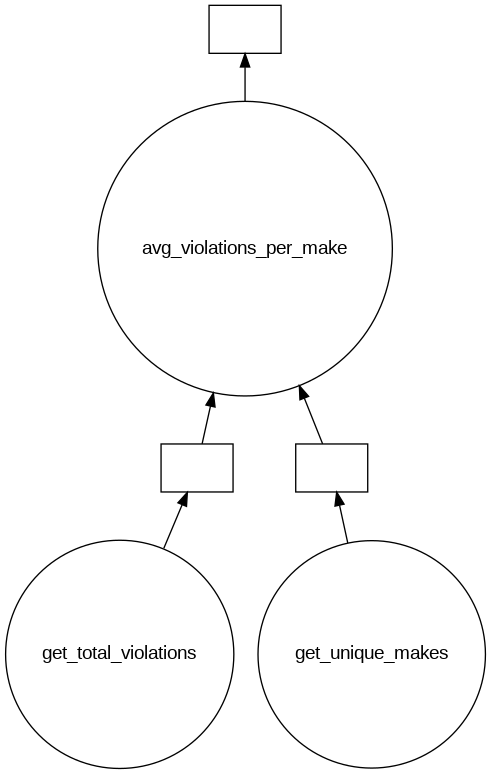

In [18]:
from dask import delayed
from IPython.display import Image

def get_total_violations():
    return len(df_final)

def get_unique_makes():
    return df_final['Vehicle Make'].nunique().compute()

def avg_violations_per_make(total, unique):
    return round(total / unique, 2)

x = delayed(get_total_violations)()
y = delayed(get_unique_makes)()
z = delayed(avg_violations_per_make)(x, y)

z.visualize(filename='simple_violation_analysis.png')
display(Image('simple_violation_analysis.png'))



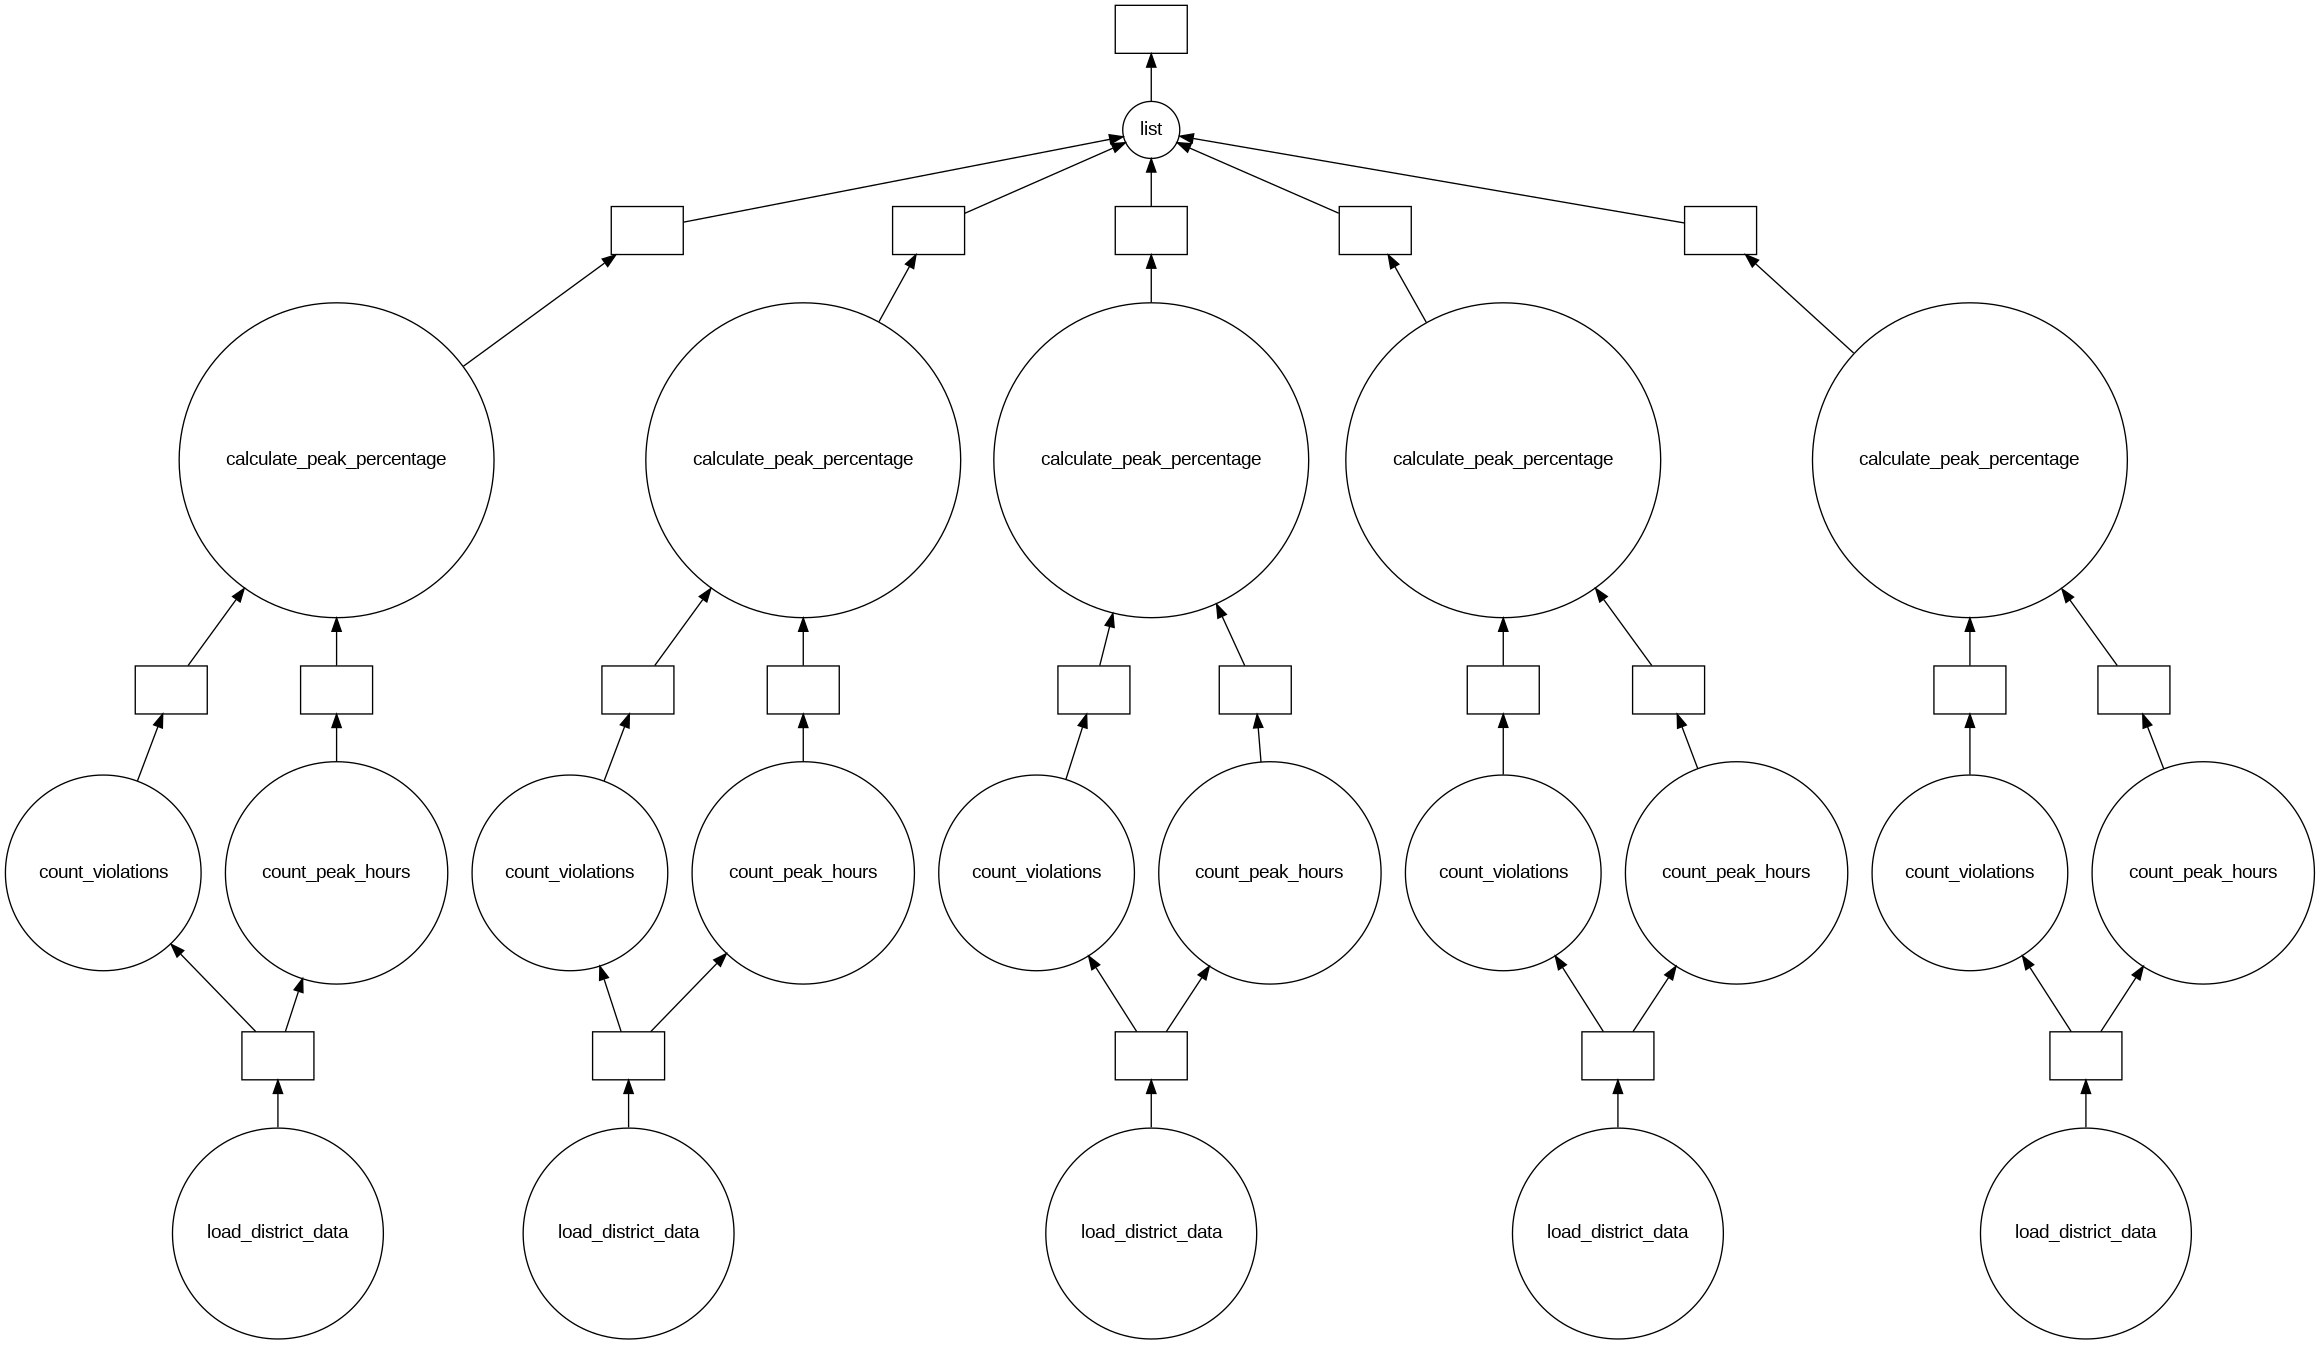

In [19]:
from dask import delayed
from IPython.display import Image
import pandas as pd

# список районов для анализа
districts = ['NY', 'K', 'Q', 'BX', 'R']  # Манхэттен, Бруклин, Квинс, Бронкс, Статен-Айленд

# данные по каждому району
def load_district_data(district):
    return df_final[df_final['Violation County'] == district]

layer1 = [delayed(load_district_data)(d) for d in districts]

# количество нарушений в районе
def count_violations(district_data):
    if district_data is None or len(district_data) == 0:
        return 0
    return len(district_data)

layer2 = [delayed(count_violations)(d) for d in layer1]

# нарушения в час-пик
def count_peak_hours(district_data):
    if district_data is None or len(district_data) == 0:
        return 0
    district_data = district_data.copy()
    district_data['Hour'] = pd.to_datetime(district_data['Violation Time'],
                                          format='%H%M', errors='coerce').dt.hour
    peak = district_data[(district_data['Hour'] >= 8) & (district_data['Hour'] <= 10)]
    return len(peak)

layer3 = [delayed(count_peak_hours)(d) for d in layer1]

# процент нарушений в час-пик
def calculate_peak_percentage(total, peak):
    if total == 0:
        return 0
    return round((peak / total) * 100, 2)

layer4 = [delayed(calculate_peak_percentage)(t, p) for t, p in zip(layer2, layer3)]

results = delayed(list)(layer4)

results.visualize(filename='complex_district_analysis.png')
display(Image('complex_district_analysis.png'))

